In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

# Project root
PROJECT_ROOT = Path.cwd().parent

# Dataset paths
DATA_DIR = PROJECT_ROOT / "data" / "raw"

TRAIN_TRANSACTION = DATA_DIR / "train_transaction.csv"
TRAIN_IDENTITY = DATA_DIR / "train_identity.csv"
TEST_TRANSACTION = DATA_DIR / "test_transaction.csv"
TEST_IDENTITY = DATA_DIR / "test_identity.csv"

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)
print("Train transaction exists:", TRAIN_TRANSACTION.exists())
print("Train identity exists:", TRAIN_IDENTITY.exists())

Project root: /Users/ayushkumar/Desktop/Fraudguard
Data directory: /Users/ayushkumar/Desktop/Fraudguard/data/raw
Train transaction exists: True
Train identity exists: True


In [3]:
# Inspect the first 5 rows of the training transaction dataset
train_sample = pd.read_csv(
    TRAIN_TRANSACTION,
    nrows=5
)

print("Rows loaded:", len(train_sample))
print("Number of columns:", len(train_sample.columns))

print("\nColumn names:")
print(train_sample.columns.tolist())

Rows loaded: 5
Number of columns: 394

Column names:
['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74'

In [4]:
# Inspect data types and basic structure

print("Data Types:")
print(train_sample.dtypes.value_counts())

print("\nFirst 5 rows:")
display(train_sample.head())

print("\nDataset Info:")
train_sample.info()

Data Types:
float64    377
object      13
int64        4
Name: count, dtype: int64

First 5 rows:


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Columns: 394 entries, TransactionID to V339
dtypes: float64(377), int64(4), object(13)
memory usage: 15.5+ KB


In [5]:
# Inspect the target variable

print("Target column:", "isFraud")

print("\nTarget values:")
print(train_sample["isFraud"].value_counts())

print("\nTarget percentages:")
print(train_sample["isFraud"].value_counts(normalize=True) * 100)

Target column: isFraud

Target values:
isFraud
0    5
Name: count, dtype: int64

Target percentages:
isFraud
0    100.0
Name: proportion, dtype: float64


In [6]:
# Calculate the actual fraud distribution using chunks
# This avoids loading the entire 658 MB dataset into memory.

fraud_counts = {0: 0, 1: 0}

for chunk in pd.read_csv(
    TRAIN_TRANSACTION,
    usecols=["isFraud"],
    chunksize=100_000
):
    counts = chunk["isFraud"].value_counts()
    
    fraud_counts[0] += counts.get(0, 0)
    fraud_counts[1] += counts.get(1, 0)

total_transactions = fraud_counts[0] + fraud_counts[1]

print("Total transactions:", f"{total_transactions:,}")
print("Legitimate transactions:", f"{fraud_counts[0]:,}")
print("Fraudulent transactions:", f"{fraud_counts[1]:,}")

print("\nFraud distribution:")
print(f"Legitimate: {fraud_counts[0] / total_transactions * 100:.4f}%")
print(f"Fraud:      {fraud_counts[1] / total_transactions * 100:.4f}%")

Total transactions: 590,540
Legitimate transactions: 569,877
Fraudulent transactions: 20,663

Fraud distribution:
Legitimate: 96.5010%
Fraud:      3.4990%


In [7]:
# Inspect the identity dataset

identity_sample = pd.read_csv(
    TRAIN_IDENTITY,
    nrows=5
)

print("Rows loaded:", len(identity_sample))
print("Number of columns:", len(identity_sample.columns))

print("\nColumn names:")
print(identity_sample.columns.tolist())

print("\nData types:")
print(identity_sample.dtypes.value_counts())

Rows loaded: 5
Number of columns: 41

Column names:
['TransactionID', 'id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06', 'id_07', 'id_08', 'id_09', 'id_10', 'id_11', 'id_12', 'id_13', 'id_14', 'id_15', 'id_16', 'id_17', 'id_18', 'id_19', 'id_20', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']

Data types:
float64    25
object     15
int64       1
Name: count, dtype: int64


In [8]:
# Count rows in the identity dataset efficiently

identity_rows = 0

for chunk in pd.read_csv(
    TRAIN_IDENTITY,
    usecols=["TransactionID"],
    chunksize=100_000
):
    identity_rows += len(chunk)

print("Total identity records:", f"{identity_rows:,}")


Total identity records: 144,233


In [10]:
# Analyze missing values in the transaction dataset
# We process the file in chunks to avoid loading the entire dataset into memory.

missing_counts = None
total_rows = 0

for chunk in pd.read_csv(
    TRAIN_TRANSACTION,
    chunksize=100_000
):
    total_rows += len(chunk)

    chunk_missing = chunk.isna().sum()

    if missing_counts is None:
        missing_counts = chunk_missing
    else:
        missing_counts += chunk_missing

missing_percentage = (missing_counts / total_rows) * 100

missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percentage": missing_percentage
})

missing_summary = missing_summary.sort_values(
    "missing_percentage",
    ascending=False
)

display(missing_summary.head(30))

,missing_count,missing_percentage
dist2,552913,93.628374
D7,551623,93.409930
D13,528588,89.509263
D14,528353,89.469469
D12,525823,89.041047
D6,517353,87.606767
D9,515614,87.312290
D8,515614,87.312290
V153,508595,86.123717
V139,508595,86.123717


In [11]:
# Investigate whether missingness itself is related to fraud

# Read only the required columns
d7_fraud = pd.read_csv(
    TRAIN_TRANSACTION,
    usecols=["D7", "isFraud"]
)

d7_fraud["D7_missing"] = d7_fraud["D7"].isna()

missing_fraud_rate = (
    d7_fraud.groupby("D7_missing")["isFraud"]
    .agg(["count", "sum", "mean"])
)

missing_fraud_rate["fraud_percentage"] = (
    missing_fraud_rate["mean"] * 100
)

missing_fraud_rate.index = [
    "D7 Present",
    "D7 Missing"
]

display(missing_fraud_rate)

,count,sum,mean,fraud_percentage
D7 Present,38917,5790,0.148778,14.877817
D7 Missing,551623,14873,0.026962,2.696226


In [12]:
# Categorize features by their missing-value percentage

missing_summary["missing_category"] = pd.cut(
    missing_summary["missing_percentage"],
    bins=[-1, 20, 50, 80, 100],
    labels=[
        "Low (<20%)",
        "Moderate (20–50%)",
        "High (50–80%)",
        "Very High (>80%)"
    ]
)

print("Features by missingness category:\n")

print(
    missing_summary["missing_category"]
    .value_counts()
    .sort_index()
)

Features by missingness category:

missing_category
Low (<20%)           182
Moderate (20–50%)     38
High (50–80%)        119
Very High (>80%)      55
Name: count, dtype: int64


In [13]:
# Identify categorical/object features

categorical_features = train_sample.select_dtypes(
    include=["object"]
).columns.tolist()

print("Categorical features:", len(categorical_features))
print()

for feature in categorical_features:
    print(feature)
    

Categorical features: 13

ProductCD
card4
card6
P_emaildomain
M1
M2
M3
M4
M5
M6
M7
M8
M9


In [14]:
# Analyze categorical feature cardinality

categorical_cardinality = []

for feature in categorical_features:
    unique_count = train_sample[feature].nunique(dropna=True)
    
    categorical_cardinality.append({
        "feature": feature,
        "unique_values_in_sample": unique_count
    })

cardinality_df = pd.DataFrame(categorical_cardinality)

display(cardinality_df)


,feature,unique_values_in_sample
0,ProductCD,2
1,card4,3
2,card6,2
3,P_emaildomain,3
4,M1,1
5,M2,1
6,M3,1
7,M4,2
8,M5,2
9,M6,2


In [15]:
# Calculate actual categorical cardinality across the full dataset

categorical_cardinality = {}

for chunk in pd.read_csv(
    TRAIN_TRANSACTION,
    usecols=categorical_features,
    chunksize=100_000
):
    for feature in categorical_features:
        values = chunk[feature].dropna().unique()
        
        if feature not in categorical_cardinality:
            categorical_cardinality[feature] = set()
        
        categorical_cardinality[feature].update(values)

cardinality_df = pd.DataFrame({
    "feature": list(categorical_cardinality.keys()),
    "unique_values": [
        len(values)
        for values in categorical_cardinality.values()
    ]
})

cardinality_df = cardinality_df.sort_values(
    "unique_values",
    ascending=False
)

display(cardinality_df)

,feature,unique_values
3,P_emaildomain,59
0,ProductCD,5
1,card4,4
2,card6,4
7,M4,3
4,M1,2
5,M2,2
6,M3,2
8,M5,2
9,M6,2


In [16]:
# Analyze missing values in the identity dataset

identity_missing_counts = None
identity_total_rows = 0

for chunk in pd.read_csv(
    TRAIN_IDENTITY,
    chunksize=100_000
):
    identity_total_rows += len(chunk)

    chunk_missing = chunk.isna().sum()

    if identity_missing_counts is None:
        identity_missing_counts = chunk_missing
    else:
        identity_missing_counts += chunk_missing

identity_missing_percentage = (
    identity_missing_counts / identity_total_rows
) * 100

identity_missing_summary = pd.DataFrame({
    "missing_count": identity_missing_counts,
    "missing_percentage": identity_missing_percentage
})

identity_missing_summary = identity_missing_summary.sort_values(
    "missing_percentage",
    ascending=False
)

display(identity_missing_summary)


,missing_count,missing_percentage
id_24,139486,96.708798
id_25,139101,96.441868
id_07,139078,96.425922
id_08,139078,96.425922
id_21,139074,96.423149
id_26,139070,96.420375
id_23,139064,96.416215
id_27,139064,96.416215
id_22,139064,96.416215
id_18,99120,68.722137


In [17]:
# Identify categorical features in the identity dataset

identity_sample = pd.read_csv(
    TRAIN_IDENTITY,
    nrows=1000
)

identity_categorical_features = identity_sample.select_dtypes(
    include=["object"]
).columns.tolist()

print("Identity categorical features:", len(identity_categorical_features))
print()

for feature in identity_categorical_features:
    print(feature)

Identity categorical features: 17

id_12
id_15
id_16
id_23
id_27
id_28
id_29
id_30
id_31
id_33
id_34
id_35
id_36
id_37
id_38
DeviceType
DeviceInfo


In [18]:
# Calculate actual categorical cardinality for the identity dataset

identity_categorical_cardinality = {}

for chunk in pd.read_csv(
    TRAIN_IDENTITY,
    usecols=identity_categorical_features,
    chunksize=50_000
):
    for feature in identity_categorical_features:
        values = chunk[feature].dropna().unique()

        if feature not in identity_categorical_cardinality:
            identity_categorical_cardinality[feature] = set()

        identity_categorical_cardinality[feature].update(values)

identity_cardinality_df = pd.DataFrame({
    "feature": list(identity_categorical_cardinality.keys()),
    "unique_values": [
        len(values)
        for values in identity_categorical_cardinality.values()
    ]
})

identity_cardinality_df = identity_cardinality_df.sort_values(
    "unique_values",
    ascending=False
)

display(identity_cardinality_df)

,feature,unique_values
16,DeviceInfo,1786
9,id_33,260
8,id_31,130
7,id_30,75
10,id_34,4
3,id_23,3
1,id_15,3
4,id_27,2
5,id_28,2
6,id_29,2


In [19]:
# Check TransactionID uniqueness in the training transaction dataset

transaction_ids = pd.read_csv(
    TRAIN_TRANSACTION,
    usecols=["TransactionID"]
)

total_ids = len(transaction_ids)
unique_ids = transaction_ids["TransactionID"].nunique()

print("Total TransactionIDs:", f"{total_ids:,}")
print("Unique TransactionIDs:", f"{unique_ids:,}")
print("Duplicate TransactionIDs:", f"{total_ids - unique_ids:,}")

Total TransactionIDs: 590,540
Unique TransactionIDs: 590,540
Duplicate TransactionIDs: 0


In [20]:
# Check TransactionID uniqueness in the identity dataset

identity_ids = pd.read_csv(
    TRAIN_IDENTITY,
    usecols=["TransactionID"]
)

total_identity_ids = len(identity_ids)
unique_identity_ids = identity_ids["TransactionID"].nunique()

print("Total identity TransactionIDs:", f"{total_identity_ids:,}")
print("Unique identity TransactionIDs:", f"{unique_identity_ids:,}")
print(
    "Duplicate identity TransactionIDs:",
    f"{total_identity_ids - unique_identity_ids:,}"
)

Total identity TransactionIDs: 144,233
Unique identity TransactionIDs: 144,233
Duplicate identity TransactionIDs: 0


In [21]:
# Verify identity-to-transaction join coverage

transaction_ids_set = set(
    pd.read_csv(
        TRAIN_TRANSACTION,
        usecols=["TransactionID"]
    )["TransactionID"]
)

identity_ids = pd.read_csv(
    TRAIN_IDENTITY,
    usecols=["TransactionID"]
)["TransactionID"]

matched = identity_ids.isin(transaction_ids_set).sum()
unmatched = len(identity_ids) - matched

print("Identity records:", f"{len(identity_ids):,}")
print("Matched transactions:", f"{matched:,}")
print("Unmatched identity records:", f"{unmatched:,}")
print("Match rate:", f"{matched / len(identity_ids) * 100:.4f}%")

Identity records: 144,233
Matched transactions: 144,233
Unmatched identity records: 0
Match rate: 100.0000%


In [1]:
# Day 2 — EDA
# Transaction amount analysis

import matplotlib.pyplot as plt

amount_data = pd.read_csv(
    TRAIN_TRANSACTION,
    usecols=["TransactionID", "TransactionAmt", "isFraud"]
)

print("Rows:", f"{len(amount_data):,}")
print("Columns:", amount_data.columns.tolist())

display(amount_data.head())

NameError: name 'pd' is not defined

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

# Project root
PROJECT_ROOT = Path.cwd().parent

# Dataset paths
DATA_DIR = PROJECT_ROOT / "data" / "raw"

TRAIN_TRANSACTION = DATA_DIR / "train_transaction.csv"
TRAIN_IDENTITY = DATA_DIR / "train_identity.csv"
TEST_TRANSACTION = DATA_DIR / "test_transaction.csv"
TEST_IDENTITY = DATA_DIR / "test_identity.csv"

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)
print("Train transaction exists:", TRAIN_TRANSACTION.exists())
print("Train identity exists:", TRAIN_IDENTITY.exists())

Project root: /Users/ayushkumar/Desktop/Fraudguard
Data directory: /Users/ayushkumar/Desktop/Fraudguard/data/raw
Train transaction exists: True
Train identity exists: True


In [3]:
# Day 2 — EDA
# Transaction amount analysis

import matplotlib.pyplot as plt

amount_data = pd.read_csv(
    TRAIN_TRANSACTION,
    usecols=["TransactionID", "TransactionAmt", "isFraud"]
)

print("Rows:", f"{len(amount_data):,}")
print("Columns:", amount_data.columns.tolist())

display(amount_data.head())

Rows: 590,540
Columns: ['TransactionID', 'isFraud', 'TransactionAmt']


,TransactionID,isFraud,TransactionAmt
0,2987000,0,68.5
1,2987001,0,29.0
2,2987002,0,59.0
3,2987003,0,50.0
4,2987004,0,50.0


In [4]:
# Overall transaction amount statistics

print("Transaction Amount Statistics")
print("=" * 40)

display(
    amount_data["TransactionAmt"].describe()
)

Transaction Amount Statistics


count    590540.000000
mean        135.027176
std         239.162522
min           0.251000
25%          43.321000
50%          68.769000
75%         125.000000
max       31937.391000
Name: TransactionAmt, dtype: float64

In [5]:
# Compare transaction amounts by fraud status

amount_by_fraud = (
    amount_data
    .groupby("isFraud")["TransactionAmt"]
    .agg([
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max"
    ])
)

amount_by_fraud.index = [
    "Legitimate",
    "Fraud"
]

display(amount_by_fraud)

,count,mean,median,std,min,max
Legitimate,569877,134.511665,68.5,239.395078,0.251,31937.391
Fraud,20663,149.244779,75.0,232.212163,0.292,5191.000


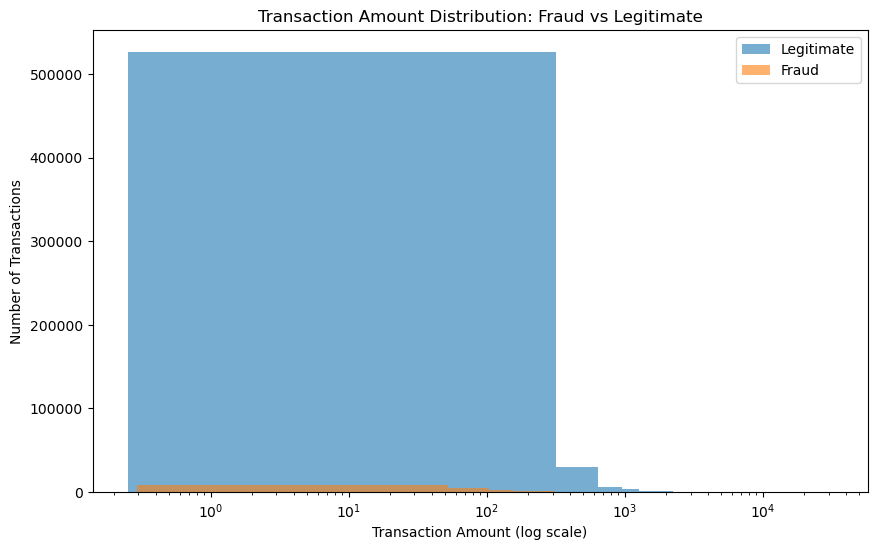

In [6]:
# Transaction amount distribution by fraud status

plt.figure(figsize=(10, 6))

plt.hist(
    amount_data.loc[amount_data["isFraud"] == 0, "TransactionAmt"],
    bins=100,
    alpha=0.6,
    label="Legitimate"
)

plt.hist(
    amount_data.loc[amount_data["isFraud"] == 1, "TransactionAmt"],
    bins=100,
    alpha=0.6,
    label="Fraud"
)

plt.xscale("log")

plt.xlabel("Transaction Amount (log scale)")
plt.ylabel("Number of Transactions")
plt.title("Transaction Amount Distribution: Fraud vs Legitimate")
plt.legend()

plt.show()

In [7]:
# Fraud rate across transaction amount ranges

amount_data["amount_bin"] = pd.qcut(
    amount_data["TransactionAmt"],
    q=10,
    duplicates="drop"
)

amount_fraud_rate = (
    amount_data
    .groupby("amount_bin", observed=True)["isFraud"]
    .agg(["count", "sum", "mean"])
)

amount_fraud_rate["fraud_percentage"] = (
    amount_fraud_rate["mean"] * 100
)

display(amount_fraud_rate)

,count,sum,mean,fraud_percentage
amount_bin,,,,
"(0.25, 25.95]",59511,3326,0.055889,5.588883
"(25.95, 35.95]",61650,1976,0.032052,3.205191
"(35.95, 49.0]",65116,2100,0.032250,3.225014
"(49.0, 57.95]",59647,1159,0.019431,1.943099
"(57.95, 68.769]",49346,1407,0.028513,2.851295
"(68.769, 100.0]",73349,2653,0.036170,3.616955
"(100.0, 117.0]",72079,1423,0.019742,1.974223
"(117.0, 159.95]",32399,1394,0.043026,4.302602
"(159.95, 275.293]",58390,2221,0.038037,3.803734


In [ ]:
### Transaction Amount — Key Findings

- Fraudulent transactions have a higher mean transaction amount (149.24) than legitimate transactions (134.51).
- Median transaction amount is also slightly higher for fraud (75.00 vs 68.50).
- Transaction amounts are strongly right-skewed, with a maximum of 31,937.39.
- Fraud rate does not increase linearly with transaction amount.
- The lowest amount decile has a relatively high fraud rate of 5.59%, while the highest decile has a fraud rate of 5.09%.
- This suggests that transaction amount may have a non-linear relationship with fraud and should be evaluated alongside other transaction characteristics.

In [8]:
# Load transaction time information

time_data = pd.read_csv(
    TRAIN_TRANSACTION,
    usecols=["TransactionID", "TransactionDT", "isFraud"]
)

print("TransactionDT statistics")
print("=" * 40)

display(time_data["TransactionDT"].describe())

TransactionDT statistics


count    5.905400e+05
mean     7.372311e+06
std      4.617224e+06
min      8.640000e+04
25%      3.027058e+06
50%      7.306528e+06
75%      1.124662e+07
max      1.581113e+07
Name: TransactionDT, dtype: float64

In [9]:
# Extract time-related features from TransactionDT

SECONDS_PER_DAY = 24 * 60 * 60

time_data["day_index"] = (
    time_data["TransactionDT"] // SECONDS_PER_DAY
)

time_data["hour"] = (
    (time_data["TransactionDT"] % SECONDS_PER_DAY) // 3600
).astype(int)

print("Day index range:")
print(
    time_data["day_index"].min(),
    "to",
    time_data["day_index"].max()
)

print("\nHour range:")
print(
    time_data["hour"].min(),
    "to",
    time_data["hour"].max()
)

display(time_data.head())

Day index range:
1 to 182

Hour range:
0 to 23


,TransactionID,isFraud,TransactionDT,day_index,hour
0,2987000,0,86400,1,0
1,2987001,0,86401,1,0
2,2987002,0,86469,1,0
3,2987003,0,86499,1,0
4,2987004,0,86506,1,0


In [10]:
# Analyze fraud rate by hour of day

fraud_by_hour = (
    time_data
    .groupby("hour")["isFraud"]
    .agg(["count", "sum", "mean"])
)

fraud_by_hour["fraud_percentage"] = (
    fraud_by_hour["mean"] * 100
)

display(fraud_by_hour)

,count,sum,mean,fraud_percentage
hour,,,,
0,37795,1186,0.031380,3.137981
1,32797,1027,0.031314,3.131384
2,26732,1002,0.037483,3.748317
3,20802,797,0.038314,3.831362
4,14839,770,0.051890,5.189029
5,9701,682,0.070302,7.030203
6,6007,467,0.077743,7.774263
7,3704,393,0.106102,10.610151
8,2591,241,0.093014,9.301428


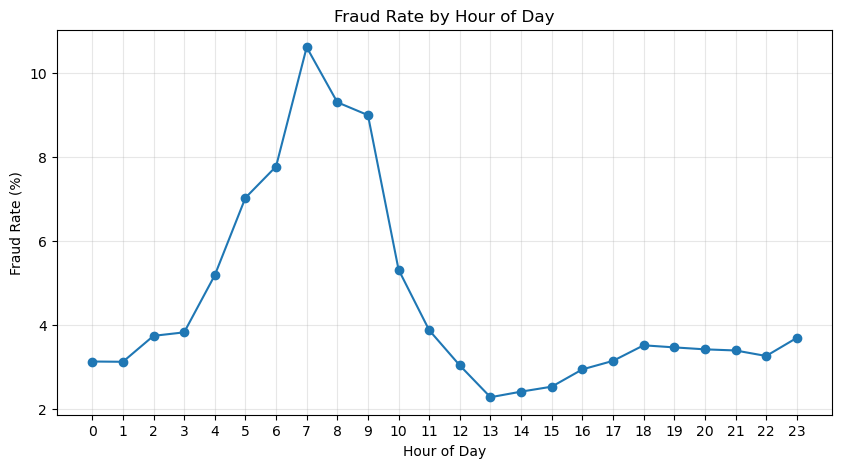

In [11]:
# Visualize fraud rate by hour

plt.figure(figsize=(10, 5))

plt.plot(
    fraud_by_hour.index,
    fraud_by_hour["fraud_percentage"],
    marker="o"
)

plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Hour of Day")
plt.xticks(range(24))

plt.grid(alpha=0.3)
plt.show()

In [ ]:
### Transaction Time — Hourly Fraud Pattern

- Fraud rates vary substantially across the relative hours encoded by `TransactionDT`.
- The highest fraud rate occurs around relative hour 7 (~10.6%), followed by hours 8 (~9.3%) and 9 (~9.0%).
- The lowest fraud rates occur around the early afternoon, with hour 13 at approximately 2.3%.
- Compared with the overall fraud rate of 3.50%, the variation across hours suggests that transaction timing contains potentially useful fraud signal.
- Because `TransactionDT` represents elapsed time rather than a real-world timestamp, the extracted hour should be interpreted as a relative time feature rather than a literal local clock hour.

In [12]:
# Analyze fraud rate across the transaction timeline

fraud_by_day = (
    time_data
    .groupby("day_index")["isFraud"]
    .agg(["count", "sum", "mean"])
)

fraud_by_day["fraud_percentage"] = (
    fraud_by_day["mean"] * 100
)

print("Number of encoded days:", len(fraud_by_day))
print(
    "Day index range:",
    fraud_by_day.index.min(),
    "to",
    fraud_by_day.index.max()
)

display(fraud_by_day.head())

Number of encoded days: 182
Day index range: 1 to 182


,count,sum,mean,fraud_percentage
day_index,,,,
1,5122,112,0.021866,2.186646
2,3730,123,0.032976,3.297587
3,3241,92,0.028386,2.838630
4,4036,115,0.028494,2.849356
5,3964,127,0.032038,3.203835


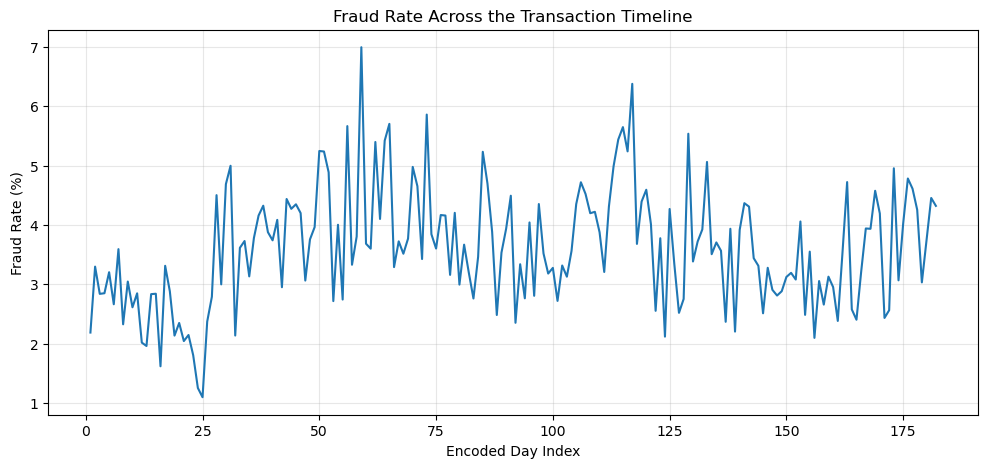

In [13]:
# Fraud rate across the encoded transaction timeline

plt.figure(figsize=(12, 5))

plt.plot(
    fraud_by_day.index,
    fraud_by_day["fraud_percentage"]
)

plt.xlabel("Encoded Day Index")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate Across the Transaction Timeline")

plt.grid(alpha=0.3)
plt.show()

In [ ]:
### Transaction Timeline — Key Findings

- Fraud rates vary across the encoded transaction timeline rather than remaining completely constant.
- Several periods show elevated fraud rates above the overall dataset rate of 3.50%.
- The timeline contains short-term fluctuations, including peaks around encoded days 60 and 115.
- Individual daily rates may be noisy because transaction volume varies across days.
- Temporal variation should be considered when designing the model validation strategy.
- `TransactionDT` represents elapsed time, so the encoded day should not be interpreted as a real calendar date.

In [14]:
# Analyze fraud by ProductCD

product_data = pd.read_csv(
    TRAIN_TRANSACTION,
    usecols=["ProductCD", "isFraud"]
)

fraud_by_product = (
    product_data
    .groupby("ProductCD")["isFraud"]
    .agg(["count", "sum", "mean"])
)

fraud_by_product["fraud_percentage"] = (
    fraud_by_product["mean"] * 100
)

display(fraud_by_product.sort_values(
    "fraud_percentage",
    ascending=False
))

,count,sum,mean,fraud_percentage
ProductCD,,,,
C,68519,8008,0.116873,11.687269
S,11628,686,0.058996,5.899553
H,33024,1574,0.047662,4.766231
R,37699,1426,0.037826,3.782594
W,439670,8969,0.020399,2.039939


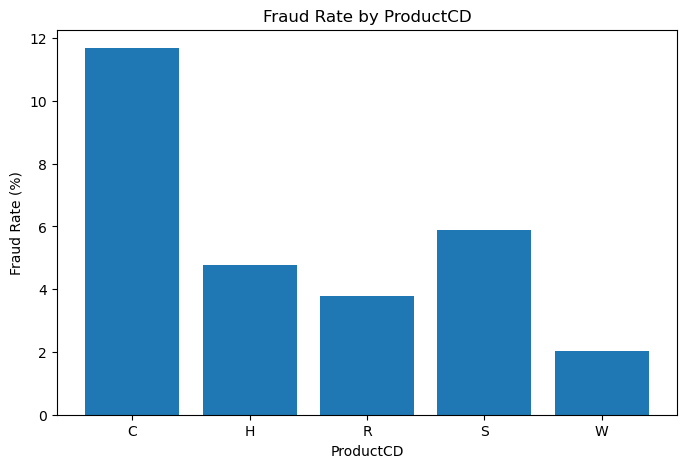

In [15]:
# Fraud rate by ProductCD

plt.figure(figsize=(8, 5))

plt.bar(
    fraud_by_product.index,
    fraud_by_product["fraud_percentage"]
)

plt.xlabel("ProductCD")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by ProductCD")

plt.show()

In [ ]:
### ProductCD — Key Findings

- Fraud rates vary substantially across the five ProductCD categories.
- ProductCD = C has the highest fraud rate at approximately 11.7%, substantially above the overall fraud rate of 3.50%.
- ProductCD = W has the lowest fraud rate at approximately 2.0%.
- The variation indicates that ProductCD contains meaningful information for fraud classification.
- ProductCD should be retained as a categorical feature rather than manually mapping categories to fraud labels.

In [16]:
# Analyze fraud by card type and card category

card_data = pd.read_csv(
    TRAIN_TRANSACTION,
    usecols=["card4", "card6", "isFraud"]
)

fraud_by_card4 = (
    card_data
    .groupby("card4")["isFraud"]
    .agg(["count", "sum", "mean"])
)

fraud_by_card4["fraud_percentage"] = (
    fraud_by_card4["mean"] * 100
)

print("Fraud by card4:")
display(
    fraud_by_card4.sort_values(
        "fraud_percentage",
        ascending=False
    )
)


fraud_by_card6 = (
    card_data
    .groupby("card6")["isFraud"]
    .agg(["count", "sum", "mean"])
)

fraud_by_card6["fraud_percentage"] = (
    fraud_by_card6["mean"] * 100
)

print("\nFraud by card6:")
display(
    fraud_by_card6.sort_values(
        "fraud_percentage",
        ascending=False
    )
)

Fraud by card4:


,count,sum,mean,fraud_percentage
card4,,,,
discover,6651,514,0.077282,7.728161
visa,384767,13373,0.034756,3.475610
mastercard,189217,6496,0.034331,3.433095
american express,8328,239,0.028698,2.869837



Fraud by card6:


,count,sum,mean,fraud_percentage
card6,,,,
credit,148986,9950,0.066785,6.678480
debit,439938,10674,0.024263,2.426251
charge card,15,0,0.000000,0.000000
debit or credit,30,0,0.000000,0.000000


In [ ]:
### Card Features — Key Findings

#### card4
- Fraud rates vary across card networks.
- Discover has the highest observed fraud rate at 7.73%, compared with the overall rate of 3.50%.
- Visa and Mastercard have fraud rates close to the overall dataset rate.
- American Express has a lower observed fraud rate of 2.87%.
- Discover should be investigated further, but its smaller sample size means the difference should not be treated as conclusive.

#### card6
- Credit transactions have a substantially higher fraud rate (6.68%) than debit transactions (2.43%).
- The `charge card` and `debit or credit` categories contain very few observations and therefore their 0% observed fraud rate is not statistically meaningful.
- `card4` and `card6` both appear to contain useful categorical information for fraud classification.

In [17]:
# Analyze fraud by purchaser email domain

email_data = pd.read_csv(
    TRAIN_TRANSACTION,
    usecols=["P_emaildomain", "isFraud"]
)

fraud_by_email = (
    email_data
    .groupby("P_emaildomain", dropna=False)["isFraud"]
    .agg(["count", "sum", "mean"])
)

fraud_by_email["fraud_percentage"] = (
    fraud_by_email["mean"] * 100
)

fraud_by_email = fraud_by_email.sort_values(
    "fraud_percentage",
    ascending=False
)

display(fraud_by_email)

,count,sum,mean,fraud_percentage
P_emaildomain,,,,
protonmail.com,76,31,0.407895,40.789474
mail.com,559,106,0.189624,18.962433
outlook.es,438,57,0.130137,13.013699
aim.com,315,40,0.126984,12.698413
outlook.com,5096,482,0.094584,9.458399
hotmail.es,305,20,0.065574,6.557377
live.com.mx,749,41,0.054740,5.473965
hotmail.com,45250,2396,0.052950,5.295028
gmail.com,228355,9943,0.043542,4.354185


In [ ]:
### P_emaildomain — Key Findings

- Fraud rates vary substantially across purchaser email domains.
- Several domains show considerably higher observed fraud rates than the overall dataset rate of 3.50%.
- ProtonMail has the highest observed rate (40.79%), but only 76 transactions, making this estimate potentially unstable.
- Larger domains such as Hotmail and Gmail provide more reliable evidence because they contain tens or hundreds of thousands of transactions.
- Missing `P_emaildomain` values occur frequently (94,456 transactions) and have an observed fraud rate of 2.95%, suggesting that missingness itself may contain information.
- Email domain appears to be a potentially useful categorical feature, but rare categories must be handled carefully during preprocessing and encoding.

In [18]:
# Analyze M1-M9 fraud rates

m_features = [
    "M1", "M2", "M3", "M4", "M5",
    "M6", "M7", "M8", "M9"
]

m_data = pd.read_csv(
    TRAIN_TRANSACTION,
    usecols=m_features + ["isFraud"]
)

m_results = []

for feature in m_features:
    grouped = (
        m_data
        .groupby(feature, dropna=False)["isFraud"]
        .agg(["count", "sum", "mean"])
        .reset_index()
    )

    grouped["feature"] = feature
    grouped["fraud_percentage"] = grouped["mean"] * 100

    m_results.append(grouped)

m_fraud_analysis = pd.concat(
    m_results,
    ignore_index=True
)

display(
    m_fraud_analysis[
        ["feature", m_fraud_analysis.columns[0],
         "count", "sum", "fraud_percentage"]
    ]
)

,feature,M1,count,sum,fraud_percentage
0,M1,F,25,0,0.000000
1,M1,T,319415,6342,1.985505
2,M1,NaN,271100,14321,5.282553
3,M2,NaN,33972,1184,3.485223
4,M2,NaN,285468,5158,1.806858
5,M2,NaN,271100,14321,5.282553
6,M3,NaN,67709,2049,3.026186
7,M3,NaN,251731,4293,1.705392
8,M3,NaN,271100,14321,5.282553
9,M4,NaN,196405,7198,3.664876


In [19]:
# Clean M1-M9 fraud analysis with explicit category column

m_results = []

for feature in m_features:
    grouped = (
        m_data
        .groupby(feature, dropna=False)["isFraud"]
        .agg(
            count="count",
            fraud_count="sum",
            fraud_rate="mean"
        )
        .reset_index()
    )

    grouped["feature"] = feature
    grouped["category"] = grouped[feature].astype("object")

    # Make missing values explicit
    grouped["category"] = grouped["category"].where(
        grouped["category"].notna(),
        "Missing"
    )

    grouped["fraud_percentage"] = grouped["fraud_rate"] * 100

    m_results.append(
        grouped[
            ["feature", "category", "count",
             "fraud_count", "fraud_percentage"]
        ]
    )

m_fraud_analysis = pd.concat(
    m_results,
    ignore_index=True
)

display(
    m_fraud_analysis.sort_values(
        ["feature", "fraud_percentage"],
        ascending=[True, False]
    )
)

,feature,category,count,fraud_count,fraud_percentage
2,M1,Missing,271100,14321,5.282553
1,M1,T,319415,6342,1.985505
0,M1,F,25,0,0.000000
5,M2,Missing,271100,14321,5.282553
3,M2,F,33972,1184,3.485223
4,M2,T,285468,5158,1.806858
8,M3,Missing,271100,14321,5.282553
6,M3,F,67709,2049,3.026186
7,M3,T,251731,4293,1.705392
11,M4,M2,59865,6809,11.373925


In [20]:
# Analyze whether missingness is associated with fraud

missingness_results = []

for feature in TRAIN_TRANSACTION_FEATURES:
    missing_flag = train_transaction[feature].isna()

    fraud_when_missing = train_transaction.loc[
        missing_flag, "isFraud"
    ].mean() * 100

    fraud_when_present = train_transaction.loc[
        ~missing_flag, "isFraud"
    ].mean() * 100

    missingness_results.append({
        "feature": feature,
        "missing_count": missing_flag.sum(),
        "missing_percentage": missing_flag.mean() * 100,
        "fraud_when_missing": fraud_when_missing,
        "fraud_when_present": fraud_when_present,
        "fraud_rate_difference": (
            fraud_when_missing - fraud_when_present
        )
    })

missingness_fraud = pd.DataFrame(
    missingness_results
)

display(
    missingness_fraud.sort_values(
        "fraud_rate_difference",
        ascending=False
    ).head(20)
)

NameError: name 'TRAIN_TRANSACTION_FEATURES' is not defined

In [21]:
# Analyze whether feature missingness is associated with fraud
# Uses chunked reading to avoid loading the full dataset into memory.

missing_counts = {}
fraud_missing_counts = {}
fraud_present_counts = {}
present_counts = {}

for chunk in pd.read_csv(
    TRAIN_TRANSACTION,
    chunksize=100_000
):
    features = [
        col for col in chunk.columns
        if col != "isFraud"
    ]

    for feature in features:
        missing = chunk[feature].isna()
        present = ~missing

        # Initialize feature
        if feature not in missing_counts:
            missing_counts[feature] = 0
            fraud_missing_counts[feature] = 0
            fraud_present_counts[feature] = 0
            present_counts[feature] = 0

        # Missing statistics
        missing_counts[feature] += missing.sum()

        fraud_missing_counts[feature] += (
            chunk.loc[missing, "isFraud"].sum()
        )

        # Present statistics
        present_counts[feature] += present.sum()

        fraud_present_counts[feature] += (
            chunk.loc[present, "isFraud"].sum()
        )

# Build summary table
missingness_results = []

total_rows = 590540

for feature in missing_counts:

    missing_count = missing_counts[feature]
    present_count = present_counts[feature]

    fraud_when_missing = (
        fraud_missing_counts[feature] / missing_count * 100
        if missing_count > 0 else np.nan
    )

    fraud_when_present = (
        fraud_present_counts[feature] / present_count * 100
        if present_count > 0 else np.nan
    )

    missingness_results.append({
        "feature": feature,
        "missing_count": missing_count,
        "missing_percentage": (
            missing_count / total_rows * 100
        ),
        "fraud_when_missing": fraud_when_missing,
        "fraud_when_present": fraud_when_present,
        "fraud_rate_difference": (
            fraud_when_missing - fraud_when_present
        )
    })

missingness_fraud = pd.DataFrame(
    missingness_results
)

missingness_fraud = missingness_fraud.sort_values(
    "fraud_rate_difference",
    ascending=False
)

display(
    missingness_fraud.head(20)
)

,feature,missing_count,missing_percentage,fraud_when_missing,fraud_when_present,fraud_rate_difference
333,V280,12,0.002032,16.666667,3.498733,13.167933
357,V304,12,0.002032,16.666667,3.498733,13.167933
350,V297,12,0.002032,16.666667,3.498733,13.167933
351,V298,12,0.002032,16.666667,3.498733,13.167933
352,V299,12,0.002032,16.666667,3.498733,13.167933
355,V302,12,0.002032,16.666667,3.498733,13.167933
356,V303,12,0.002032,16.666667,3.498733,13.167933
365,V312,12,0.002032,16.666667,3.498733,13.167933
358,V305,12,0.002032,16.666667,3.498733,13.167933
370,V317,12,0.002032,16.666667,3.498733,13.167933


In [22]:
# Filter missingness analysis to statistically meaningful group sizes

meaningful_missingness = missingness_fraud[
    (missingness_fraud["missing_count"] >= 1000) &
    (
        (590540 - missingness_fraud["missing_count"]) >= 1000
    )
].copy()

meaningful_missingness = meaningful_missingness.sort_values(
    "fraud_rate_difference",
    ascending=False
)

display(
    meaningful_missingness.head(20)
)

,feature,missing_count,missing_percentage,fraud_when_missing,fraud_when_present,fraud_rate_difference
11,addr2,65706,11.126427,11.781268,2.462112,9.319156
10,addr1,65706,11.126427,11.781268,2.462112,9.319156
50,M6,169360,28.678836,7.068375,2.063726,5.004649
47,M3,271100,45.907136,5.282553,1.985349,3.297203
45,M1,271100,45.907136,5.282553,1.985349,3.297203
46,M2,271100,45.907136,5.282553,1.985349,3.297203
58,V5,279287,47.293494,5.212201,1.961748,3.250453
40,D11,279287,47.293494,5.212201,1.961748,3.250453
59,V6,279287,47.293494,5.212201,1.961748,3.250453
56,V3,279287,47.293494,5.212201,1.961748,3.250453


In [23]:
# Features where presence is associated with higher fraud

display(
    meaningful_missingness.sort_values(
        "fraud_rate_difference",
        ascending=True
    ).head(20)
)

,feature,missing_count,missing_percentage,fraud_when_missing,fraud_when_present,fraud_rate_difference
36,D7,551623,93.409930,2.696226,14.877817,-12.181591
41,D12,525823,89.041047,2.484676,11.740346,-9.255670
43,D14,528353,89.469469,2.545647,11.598887,-9.053241
42,D13,528588,89.509263,2.615648,11.035963,-8.420316
35,D6,517353,87.606767,2.502160,10.545589,-8.043429
38,D9,515614,87.312290,2.489459,10.446307,-7.956848
37,D8,515614,87.312290,2.489459,10.446307,-7.956848
13,dist2,552913,93.628374,3.062326,9.915752,-6.853426
15,R_emaildomain,453249,76.751617,2.081858,8.177521,-6.095663
251,V198,450721,76.323534,2.128368,7.917379,-5.789011


In [24]:
# Analyze total missing-feature count per transaction

missing_count_data = pd.read_csv(
    TRAIN_TRANSACTION,
    usecols=lambda col: col != "isFraud"
)

missing_count_data["missing_feature_count"] = (
    missing_count_data.isna().sum(axis=1)
)

missing_count_data["isFraud"] = pd.read_csv(
    TRAIN_TRANSACTION,
    usecols=["isFraud"]
)["isFraud"]

missing_count_analysis = (
    missing_count_data
    .groupby("missing_feature_count")["isFraud"]
    .agg(["count", "sum", "mean"])
)

missing_count_analysis["fraud_percentage"] = (
    missing_count_analysis["mean"] * 100
)

display(
    missing_count_analysis
)

,count,sum,mean,fraud_percentage
missing_feature_count,,,,
23,20,0,0.000000,0.000000
24,67,2,0.029851,2.985075
25,103,1,0.009709,0.970874
26,162,0,0.000000,0.000000
27,163,0,0.000000,0.000000
...,...,...,...,...
288,1,0,0.000000,0.000000
290,1,0,0.000000,0.000000
292,5,0,0.000000,0.000000


In [25]:
# Group transactions by the number of missing features

missing_count_data["missing_bin"] = pd.cut(
    missing_count_data["missing_feature_count"],
    bins=[0, 50, 100, 150, 200, 250, 300, float("inf")],
    labels=[
        "0–50",
        "51–100",
        "101–150",
        "151–200",
        "201–250",
        "251–300",
        "301+"
    ],
    include_lowest=True
)

missing_bin_analysis = (
    missing_count_data
    .groupby("missing_bin", observed=True)["isFraud"]
    .agg(
        count="count",
        fraud_count="sum",
        fraud_rate="mean"
    )
)

missing_bin_analysis["fraud_percentage"] = (
    missing_bin_analysis["fraud_rate"] * 100
)

display(missing_bin_analysis)

,count,fraud_count,fraud_rate,fraud_percentage
missing_bin,,,,
0–50,3828,38,0.009927,0.992685
51–100,58061,6694,0.115293,11.529254
101–150,75974,4150,0.054624,5.462395
151–200,415619,8652,0.020817,2.081714
201–250,36507,1064,0.029145,2.914510
251–300,551,65,0.117967,11.796733


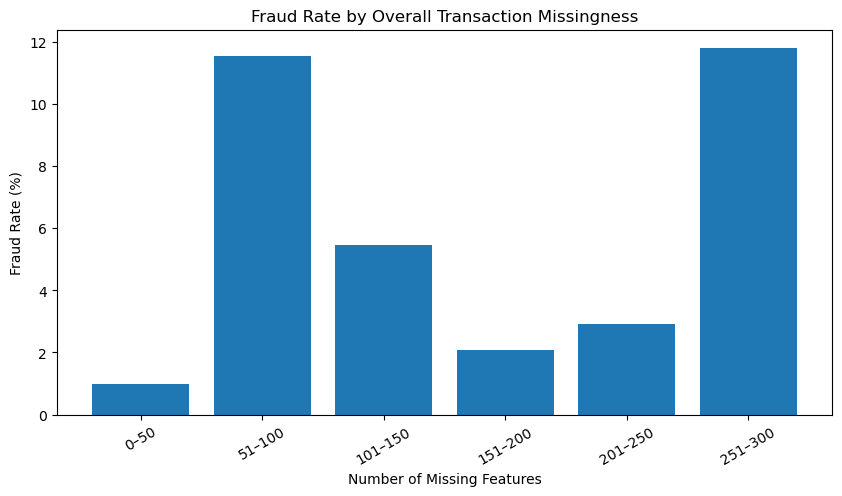

In [26]:
# Fraud rate by missing-feature-count range

plt.figure(figsize=(10, 5))

plt.bar(
    missing_bin_analysis.index.astype(str),
    missing_bin_analysis["fraud_percentage"]
)

plt.xlabel("Number of Missing Features")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Overall Transaction Missingness")

plt.xticks(rotation=30)
plt.show()

In [27]:
display(
    missing_bin_analysis[
        ["count", "fraud_count", "fraud_percentage"]
    ]
)

,count,fraud_count,fraud_percentage
missing_bin,,,
0–50,3828,38,0.992685
51–100,58061,6694,11.529254
101–150,75974,4150,5.462395
151–200,415619,8652,2.081714
201–250,36507,1064,2.914510
251–300,551,65,11.796733


In [ ]:
### Overall Missingness — Key Findings

- The number of missing features per transaction shows a non-linear relationship with fraud.
- Transactions with 51–100 missing features have an observed fraud rate of 11.53% across 58,061 transactions.
- Transactions with 101–150 missing features have a fraud rate of 5.46%.
- The largest group, 151–200 missing features, has a comparatively low fraud rate of 2.08%.
- The 251–300 range shows an elevated fraud rate of 11.80%, but only 551 transactions fall in this range and therefore the estimate should be treated cautiously.
- Overall, missingness count appears to contain potentially useful information, but the relationship is not monotonic.
- `missing_feature_count` will be treated as a candidate engineered feature and evaluated during model validation rather than being automatically included.

In [28]:
# Analyze fraud rate based on whether identity information exists

transaction_ids = pd.read_csv(
    TRAIN_TRANSACTION,
    usecols=["TransactionID", "isFraud"]
)

identity_ids = pd.read_csv(
    TRAIN_IDENTITY,
    usecols=["TransactionID"]
)

identity_id_set = set(identity_ids["TransactionID"])

transaction_ids["identity_present"] = (
    transaction_ids["TransactionID"].isin(identity_id_set)
)

identity_presence_analysis = (
    transaction_ids
    .groupby("identity_present")["isFraud"]
    .agg(
        count="count",
        fraud_count="sum",
        fraud_rate="mean"
    )
)

identity_presence_analysis["fraud_percentage"] = (
    identity_presence_analysis["fraud_rate"] * 100
)

display(identity_presence_analysis)

,count,fraud_count,fraud_rate,fraud_percentage
identity_present,,,,
False,446307,9345,0.020939,2.093850
True,144233,11318,0.078470,7.847025


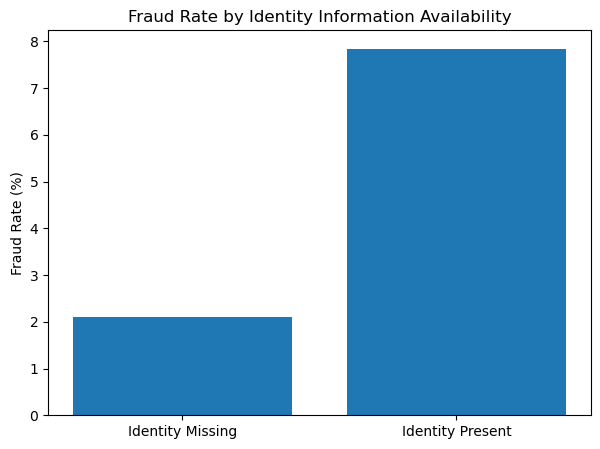

In [29]:
# Fraud rate based on identity availability

plt.figure(figsize=(7, 5))

plt.bar(
    ["Identity Missing", "Identity Present"],
    [
        identity_presence_analysis.loc[False, "fraud_percentage"],
        identity_presence_analysis.loc[True, "fraud_percentage"]
    ]
)

plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Identity Information Availability")

plt.show()

In [ ]:
### Identity Availability — Key Findings

- Identity information is available for 144,233 of 590,540 transactions (~24.4%).
- Transactions with identity information have an observed fraud rate of 7.85%.
- Transactions without identity information have an observed fraud rate of 2.09%.
- This represents a difference of approximately 5.75 percentage points.
- The presence of an identity record is therefore strongly associated with fraud and may be a useful feature for the model.
- This association should not be interpreted as identity information causing fraud.
- Transactions without identity records should be retained during preprocessing, with identity features handled as missing values and an explicit identity-availability indicator considered as a candidate feature.

In [30]:
# Numerical identity features

identity_sample = pd.read_csv(
    TRAIN_IDENTITY,
    usecols=["TransactionID", "isFraud"]
)

ValueError: Usecols do not match columns, columns expected but not found: ['isFraud']

In [31]:
# Load identity data and target

identity_data = pd.read_csv(
    TRAIN_IDENTITY
)

identity_target = pd.read_csv(
    TRAIN_TRANSACTION,
    usecols=["TransactionID", "isFraud"]
)

identity_data = identity_data.merge(
    identity_target,
    on="TransactionID",
    how="left"
)

print("Identity rows:", len(identity_data))
print("Columns:", len(identity_data.columns))

display(identity_data.head())

Identity rows: 144233
Columns: 42


,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,isFraud
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M,0
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device,0
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,NaN,NaN,NaN,F,F,T,T,desktop,Windows,0
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,NaN,NaN,NaN,F,F,T,T,desktop,NaN,0
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS,0


In [32]:
# Identify numerical identity features

identity_numeric_features = identity_data.select_dtypes(
    include=["number"]
).columns.tolist()

identity_numeric_features.remove("TransactionID")
identity_numeric_features.remove("isFraud")

print("Numerical identity features:", len(identity_numeric_features))
print(identity_numeric_features)

Numerical identity features: 23
['id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06', 'id_07', 'id_08', 'id_09', 'id_10', 'id_11', 'id_13', 'id_14', 'id_17', 'id_18', 'id_19', 'id_20', 'id_21', 'id_22', 'id_24', 'id_25', 'id_26', 'id_32']


In [33]:
# Compare numerical identity features between legitimate and fraudulent transactions

numeric_comparison = []

for feature in identity_numeric_features:

    legitimate = identity_data.loc[
        identity_data["isFraud"] == 0, feature
    ]

    fraud = identity_data.loc[
        identity_data["isFraud"] == 1, feature
    ]

    numeric_comparison.append({
        "feature": feature,
        "missing_percentage": identity_data[feature].isna().mean() * 100,

        "legitimate_mean": legitimate.mean(),
        "fraud_mean": fraud.mean(),

        "legitimate_median": legitimate.median(),
        "fraud_median": fraud.median(),

        "median_difference": (
            fraud.median() - legitimate.median()
        )
    })

numeric_comparison = pd.DataFrame(numeric_comparison)

display(
    numeric_comparison.sort_values(
        "median_difference",
        key=abs,
        ascending=False
    )
)


,feature,missing_percentage,legitimate_mean,fraud_mean,legitimate_median,fraud_median,median_difference
1,id_02,2.330257,172396.362892,201522.569239,124125.0,149599.5,25474.5
13,id_17,3.372321,188.113697,204.991400,166.0,225.0,59.0
15,id_19,3.407681,354.854950,333.060156,341.0,290.0,-51.0
16,id_20,3.447200,401.133705,435.838002,469.0,507.0,38.0
21,id_26,96.420375,148.112917,159.743529,147.0,161.0,14.0
6,id_07,96.425922,13.574963,10.070423,14.0,8.0,-6.0
7,id_08,96.425922,-38.150349,-43.596244,-34.0,-36.0,-2.0
0,id_01,0.000000,-9.667667,-16.075632,-5.0,-5.0,0.0
20,id_25,96.441868,328.622269,340.764988,321.0,321.0,0.0
19,id_24,96.708798,12.802301,12.786070,11.0,11.0,0.0


In [34]:
# Analyze fraud rate across quantiles for numerical identity features

quantile_results = []

for feature in identity_numeric_features:

    temp = identity_data[[feature, "isFraud"]].dropna().copy()

    # Need enough unique values to create quantile bins
    if temp[feature].nunique() < 5:
        continue

    try:
        temp["bin"] = pd.qcut(
            temp[feature],
            q=5,
            duplicates="drop"
        )

        grouped = (
            temp
            .groupby("bin", observed=True)["isFraud"]
            .agg(
                count="count",
                fraud_count="sum",
                fraud_rate="mean"
            )
            .reset_index()
        )

        grouped["feature"] = feature
        grouped["fraud_percentage"] = (
            grouped["fraud_rate"] * 100
        )

        quantile_results.append(grouped)

    except ValueError:
        pass

identity_quantile_analysis = pd.concat(
    quantile_results,
    ignore_index=True
)

display(identity_quantile_analysis.head(30))

,bin,count,fraud_count,fraud_rate,feature,fraud_percentage
0,"(-100.001, -15.0]",31176,4229,0.135649,id_01,13.564922
1,"(-15.0, -5.0]",93502,6116,0.065410,id_01,6.541037
2,"(-5.0, 0.0]",19555,973,0.049757,id_01,4.975710
3,"(0.999, 56999.0]",28176,1821,0.064629,id_02,6.462947
4,"(56999.0, 101329.4]",28173,1935,0.068683,id_02,6.868278
5,"(101329.4, 157307.4]",28174,2103,0.074643,id_02,7.464329
6,"(157307.4, 265238.8]",28174,2499,0.088699,id_02,8.869880
7,"(265238.8, 999595.0]",28175,2864,0.101650,id_02,10.165040
8,"(-13.001, 0.0]",64090,6560,0.102356,id_03,10.235606
9,"(0.0, 10.0]",2234,552,0.247090,id_03,24.709042


In [35]:
# Analyze fraud rate across quantiles for numerical identity features

quantile_results = []

for feature in identity_numeric_features:

    temp = identity_data[[feature, "isFraud"]].dropna().copy()

    if temp[feature].nunique() < 5:
        continue

    try:
        temp["bin"] = pd.qcut(
            temp[feature],
            q=5,
            duplicates="drop"
        )

        grouped = (
            temp
            .groupby("bin", observed=True)["isFraud"]
            .agg(
                count="count",
                fraud_count="sum",
                fraud_rate="mean"
            )
            .reset_index()
        )

        grouped["feature"] = feature
        grouped["fraud_percentage"] = (
            grouped["fraud_rate"] * 100
        )

        quantile_results.append(grouped)

    except ValueError:
        pass

identity_quantile_analysis = pd.concat(
    quantile_results,
    ignore_index=True
)

display(identity_quantile_analysis.head(30))

,bin,count,fraud_count,fraud_rate,feature,fraud_percentage
0,"(-100.001, -15.0]",31176,4229,0.135649,id_01,13.564922
1,"(-15.0, -5.0]",93502,6116,0.065410,id_01,6.541037
2,"(-5.0, 0.0]",19555,973,0.049757,id_01,4.975710
3,"(0.999, 56999.0]",28176,1821,0.064629,id_02,6.462947
4,"(56999.0, 101329.4]",28173,1935,0.068683,id_02,6.868278
5,"(101329.4, 157307.4]",28174,2103,0.074643,id_02,7.464329
6,"(157307.4, 265238.8]",28174,2499,0.088699,id_02,8.869880
7,"(265238.8, 999595.0]",28175,2864,0.101650,id_02,10.165040
8,"(-13.001, 0.0]",64090,6560,0.102356,id_03,10.235606
9,"(0.0, 10.0]",2234,552,0.247090,id_03,24.709042


In [36]:
display(
    identity_quantile_analysis[
        identity_quantile_analysis["feature"] == "id_02"
    ]
)

,bin,count,fraud_count,fraud_rate,feature,fraud_percentage
3,"(0.999, 56999.0]",28176,1821,0.064629,id_02,6.462947
4,"(56999.0, 101329.4]",28173,1935,0.068683,id_02,6.868278
5,"(101329.4, 157307.4]",28174,2103,0.074643,id_02,7.464329
6,"(157307.4, 265238.8]",28174,2499,0.088699,id_02,8.869880
7,"(265238.8, 999595.0]",28175,2864,0.101650,id_02,10.165040


In [37]:
# Measure fraud-rate spread across quantiles for each numerical identity feature

identity_feature_strength = (
    identity_quantile_analysis
    .groupby("feature")["fraud_percentage"]
    .agg(
        min_fraud_rate="min",
        max_fraud_rate="max"
    )
)

identity_feature_strength["fraud_rate_range"] = (
    identity_feature_strength["max_fraud_rate"]
    - identity_feature_strength["min_fraud_rate"]
)

display(
    identity_feature_strength.sort_values(
        "fraud_rate_range",
        ascending=False
    )
)


,min_fraud_rate,max_fraud_rate,fraud_rate_range
feature,,,
id_03,10.235606,24.709042,14.473436
id_14,2.870760,16.666667,13.795906
id_22,7.296499,18.735363,11.438864
id_09,9.939160,19.241126,9.301967
id_17,4.344843,12.987530,8.642688
id_01,4.975710,13.564922,8.589212
id_07,6.097561,13.636364,7.538803
id_26,4.679626,12.037833,7.358208
id_21,5.446009,12.768131,7.322121


In [38]:
# Select strongest numerical identity features

top_identity_features = (
    identity_feature_strength
    .sort_values(
        "fraud_rate_range",
        ascending=False
    )
    .head(5)
    .index
    .tolist()
)

print("Top numerical identity features:")
print(top_identity_features)

Top numerical identity features:
['id_03', 'id_14', 'id_22', 'id_09', 'id_17']


In [39]:
# Display quantile fraud rates for the top identity features

top_identity_quantiles = identity_quantile_analysis[
    identity_quantile_analysis["feature"].isin(
        top_identity_features
    )
].copy()

display(
    top_identity_quantiles[
        [
            "feature",
            "bin",
            "count",
            "fraud_count",
            "fraud_percentage"
        ]
    ]
)

,feature,bin,count,fraud_count,fraud_percentage
8,id_03,"(-13.001, 0.0]",64090,6560,10.235606
9,id_03,"(0.0, 10.0]",2234,552,24.709042
26,id_09,"(-36.001, 0.0]",70841,7041,9.939160
27,id_09,"(0.0, 25.0]",4085,786,19.241126
33,id_14,"(-660.001, -420.0]",18044,518,2.870760
34,id_14,"(-420.0, -360.0]",16661,734,4.405498
35,id_14,"(-360.0, -300.0]",44121,2124,4.814034
36,id_14,"(-300.0, 720.0]",1218,203,16.666667
37,id_17,"(99.999, 166.0]",81614,3546,4.344843
38,id_17,"(166.0, 225.0]",57740,7499,12.987530


In [40]:
# Analyze categorical identity features

identity_categorical_features = [
    "id_12", "id_15", "id_16", "id_23",
    "id_27", "id_28", "id_29", "id_30",
    "id_31", "id_33", "id_34", "id_35",
    "id_36", "id_37", "id_38",
    "DeviceType", "DeviceInfo"
]

categorical_summary = []

for feature in identity_categorical_features:

    temp = identity_data[[feature, "isFraud"]].copy()

    grouped = (
        temp
        .groupby(feature, dropna=False)["isFraud"]
        .agg(
            count="count",
            fraud_count="sum",
            fraud_rate="mean"
        )
    )

    categorical_summary.append({
        "feature": feature,
        "unique_values": identity_data[feature].nunique(
            dropna=True
        ),
        "missing_percentage": (
            identity_data[feature].isna().mean() * 100
        ),
        "largest_category_count": grouped["count"].max(),
        "max_fraud_rate": grouped["fraud_rate"].max() * 100,
        "min_fraud_rate": grouped["fraud_rate"].min() * 100
    })

categorical_summary = pd.DataFrame(
    categorical_summary
)

display(
    categorical_summary.sort_values(
        "max_fraud_rate",
        ascending=False
    )
)

,feature,unique_values,missing_percentage,largest_category_count,max_fraud_rate,min_fraud_rate
8,id_31,130,2.739318,22000,100.000000,0.000000
9,id_33,260,49.187079,70944,100.000000,0.000000
16,DeviceInfo,1786,17.726179,47722,100.000000,0.000000
7,id_30,75,46.222432,66668,60.000000,0.000000
3,id_23,3,96.416215,139064,13.725490,5.582923
11,id_35,2,2.251912,77814,12.260373,2.955665
10,id_34,4,46.056034,66428,11.791714,0.000000
2,id_16,2,10.325654,66324,10.723117,4.824172
1,id_15,3,2.251912,67728,10.509686,2.955665
6,id_29,2,2.256765,74926,10.446307,3.072197


In [41]:
# Analyze categorical identity features while excluding tiny categories

categorical_category_results = []

for feature in identity_categorical_features:

    grouped = (
        identity_data
        .groupby(feature, dropna=False)["isFraud"]
        .agg(
            count="count",
            fraud_count="sum",
            fraud_rate="mean"
        )
        .reset_index()
    )

    # Keep only categories with sufficient observations
    grouped = grouped[grouped["count"] >= 500].copy()

    grouped["feature"] = feature
    grouped["fraud_percentage"] = (
        grouped["fraud_rate"] * 100
    )

    categorical_category_results.append(
        grouped
    )

categorical_category_analysis = pd.concat(
    categorical_category_results,
    ignore_index=True
)

display(
    categorical_category_analysis[
        [
            "feature",
            "count",
            "fraud_count",
            "fraud_percentage"
        ]
    ].sort_values(
        "fraud_percentage",
        ascending=False
    ).head(30)
)

,feature,count,fraud_count,fraud_percentage
65,id_31,673,147,21.842496
61,id_31,4778,803,16.806195
56,id_31,3473,552,15.894040
58,id_31,3336,491,14.718225
83,id_33,1318,181,13.732929
9,id_23,1071,147,13.725490
50,id_31,538,72,13.382900
60,id_31,2349,305,12.984249
104,id_35,63171,7745,12.260373
44,id_30,1200,146,12.166667
